Data Visualisation
---

In this notebook we look at the data we are working with. Unlike the simpler `nsbi_atlas_workshop` example (where every feature is a single Gaussian), here each sample is a **mixture of several correlated Gaussian components**. This produces multi-modal marginals and curved correlations that a single Gaussian cannot capture — a genuinely non-trivial density that is a good stress test for flexible density estimators such as Normalizing Flows.

Every sample also shares a common broad component, which guarantees overlapping support so that the density ratios we train later stay numerically well behaved. See the README for how to generate the data with `generate_distributions.py`.


In [1]:
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
hep.set_style("ATLAS")

/var/folders/6j/4vrgsq1j2_z2njj71mnjsqvc0000gn/T/ipykernel_34001/718821075.py:5: FutureWarning: ``set_style`` is deprecated: Naming convention is changing to match mpl. Use ``mplhep.style.use()``.
  hep.set_style("ATLAS")


In [2]:
BASE_PATH = "./dataframes/"

In [3]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Visualising the dataset

Before training the NN, lets take a look at what the "kinematics" of the final state look like.

Note how some variables are more discriminating than others, and how several of them are **multi-modal** (more than one bump). Our goal with SBI is to use all of the variables — including their high-dimensional correlations — to build the model.


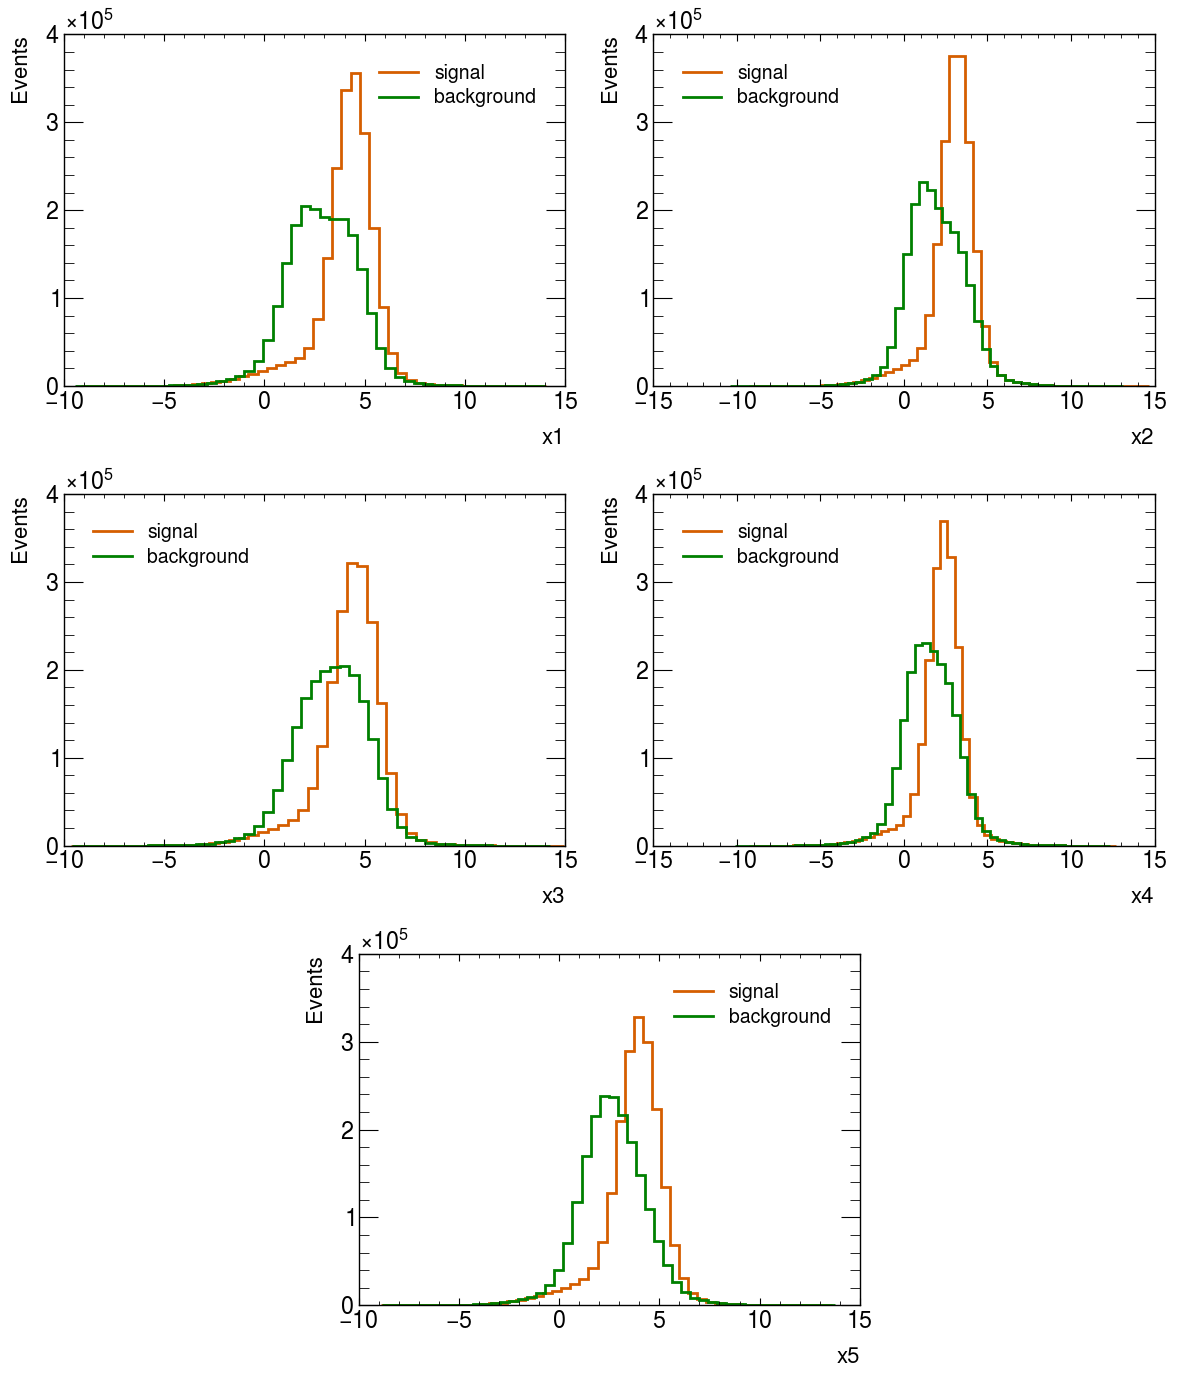

In [4]:
variables = ["x1", "x2", "x3", "x4", "x5"]

mosaic = [
    ["x1", "x1", "x2", "x2"],
    ["x3", "x3", "x4", "x4"],
    [".",  "x5", "x5", "."],
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(12, 14))

for var in variables:
    ax = axes[var]

    x_sig = np.array(signal[var])
    h_sig, bins = np.histogram(x_sig, bins=50)
    hep.histplot(h_sig, bins, ax=ax, label="signal", linewidth=2.0)

    x_bkg = np.array(background[var])
    h_bkg, bins = np.histogram(x_bkg, bins=50)
    hep.histplot(h_bkg, bins, ax=ax, label="background", linewidth=2.0, color="green")

    ax.legend(fontsize=14)
    ax.set_xlabel(var, size=16)
    ax.set_ylabel("Events", size=16)

fig.tight_layout()
